In [ ]:
!pip install tqdm
!pip install gensim
!pip install seqeval
!pip install pytorch-crf

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [74]:
import json
import pandas as pd
import numpy as np
import torch
import os
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from seqeval.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load Data

In [ ]:
path = 
data_path1 = os.path.join(path, 'data_label_1.csv')
data_path2 = os.path.join(path, 'data_label_2.csv')
data_path3 = os.path.join(path, 'data_label_3.csv')

In [76]:
df1 = pd.read_csv(data_path1)
df1.drop(columns=['annotation_id', 'annotator', 'created_at','id','updated_at','lead_time'], inplace=True)
df1.head()

,label,text
0,"[{""start"":22,""end"":34,""text"":""88 play 2024"",""l...",cần pass vợt cầu_lông 88 play 2024 đánh được 2...
1,"[{""start"":0,""end"":12,""text"":""Vợt cầu_lông"",""la...","Vợt cầu_lông Haojian màu đen , cam , đỏ , thiế..."
2,"[{""start"":0,""end"":12,""text"":""Vợt cầu_lông"",""la...",Vợt cầu_lông Prokennex_Stormbreaker 618 màu đe...
3,"[{""start"":3,""end"":6,""text"":""vợt"",""labels"":[""PR...",Xả vợt Sale mạnh cho ae chơi tết Đủ các mã vợt...
4,"[{""start"":14,""end"":17,""text"":""vợt"",""labels"":[""...",Mình cần pass vợt Victor_TK 220h II 99% cước 1...


In [77]:
df2 = pd.read_csv(data_path2)
df2.drop(columns=['annotation_id', 'annotator', 'created_at','id','updated_at','lead_time'], inplace=True)
df2.head()

,label,text
0,"[{""start"":314,""end"":322,""text"":""21000000"",""lab...",Laptop_Acer_Nitro_V ANV 15-52 - Bảo_hành chính...
1,"[{""start"":447,""end"":534,""text"":""D \/ C : 28 đư...",Laptop_Xiaomi_Redmibook_Pro 15 2022 màu xám : ...
2,"[{""start"":8,""end"":24,""text"":""Surface laptop 3""...",Em pass Surface laptop 3 i 5-103 5G 7 RAM 8Gb ...
3,"[{""start"":0,""end"":13,""text"":""SURFACE PRO 8"",""l...",SURFACE PRO 8 ( i 5/8 / 256 ) Giá chỉ từ : 100...
4,"[{""start"":303,""end"":311,""text"":""10000000"",""lab...",Laptop_Asus_Vivobook_Pro 15 OLED M6500QC Gamin...


In [78]:
df3 = pd.read_csv(data_path3)
df3.drop(columns=['annotation_id', 'annotator', 'created_at','id','updated_at','lead_time'], inplace=True)
df3.head()

,label,text
0,"[{""start"":22,""end"":33,""text"":""Samsung S21"",""la...","giá 5900000 mình pass Samsung S21 5G 8/128 ạ ,..."
1,"[{""start"":64,""end"":74,""text"":""điện_thoại"",""lab...",gdtt Hải_Dương giá 350000 vnd mình thanh_lý má...
2,"[{""start"":9,""end"":35,""text"":""phông_nền chụp ản...","mình bán phông_nền chụp ảnh 1.6 x2m ạ , màu tr..."
3,"[{""start"":31,""end"":58,""text"":""máy đóng gáy lò_...",gdtt Cầu_Giấy Hà_Nội mình pass máy đóng gáy lò...
4,"[{""start"":25,""end"":41,""text"":"" iPhone 13 128gb...","giá 8500000 mình thanh_lý iPhone 13 128gb ạ , ..."


In [79]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df.head()

,label,text
0,"[{""start"":22,""end"":34,""text"":""88 play 2024"",""l...",cần pass vợt cầu_lông 88 play 2024 đánh được 2...
1,"[{""start"":0,""end"":12,""text"":""Vợt cầu_lông"",""la...","Vợt cầu_lông Haojian màu đen , cam , đỏ , thiế..."
2,"[{""start"":0,""end"":12,""text"":""Vợt cầu_lông"",""la...",Vợt cầu_lông Prokennex_Stormbreaker 618 màu đe...
3,"[{""start"":3,""end"":6,""text"":""vợt"",""labels"":[""PR...",Xả vợt Sale mạnh cho ae chơi tết Đủ các mã vợt...
4,"[{""start"":14,""end"":17,""text"":""vợt"",""labels"":[""...",Mình cần pass vợt Victor_TK 220h II 99% cước 1...


In [ ]:
print(len(df1))
print(len(df2))
print(len(df3))
print(len(df))

# Tagging

In [111]:
label_list = [
    'O',
    'B-PROUCT_TYPE','I-PROUCT_TYPE',
    'B-PROUCT_NAME','I-PROUCT_NAME',
    'B-PRICE','I-PRICE',
    'B-LOCATION','I-LOCATION'
]
label2id = {l:i for i,l in enumerate(label_list)}
id2label = {i:l for l,i in label2id.items()}

In [85]:
def tagging(full_text, annotation):

  words = []
  word_index = []
  current_index = 0
  for word in full_text.split(" "):
    word_start = full_text.find(word, current_index)
    word_end = word_start + len(word)
    words.append(word)
    word_index.append((word_start, word_end))
    current_index = word_end
    tag_seq = ['O']*len(words)
  anno_list = json.loads(annotation)
  for ann in anno_list:
    ann_start = ann['start']
    ann_end = ann['end']
    ann_type = ann['labels'][0]

    entity_start = False
    for i, (w_start, w_end) in enumerate(word_index):
      if ann_start <= w_start and w_end <= ann_end:
        if not entity_start:
          tag_seq[i] = f"B-{ann_type}"
          entity_start = True
        else:
          tag_seq[i] = f"I-{ann_type}"
  return  tag_seq

In [86]:
df['tag_seg'] = df.apply(lambda x: tagging(x['text'], x['label']), axis=1)

In [87]:
df.head()

,label,text,tag_seg
0,"[{""start"":22,""end"":34,""text"":""88 play 2024"",""l...",cần pass vợt cầu_lông 88 play 2024 đánh được 2...,"[O, O, B-PROUCT_TYPE, I-PROUCT_TYPE, B-PROUCT_..."
1,"[{""start"":0,""end"":12,""text"":""Vợt cầu_lông"",""la...","Vợt cầu_lông Haojian màu đen , cam , đỏ , thiế...","[B-PROUCT_TYPE, I-PROUCT_TYPE, B-PROUCT_NAME, ..."
2,"[{""start"":0,""end"":12,""text"":""Vợt cầu_lông"",""la...",Vợt cầu_lông Prokennex_Stormbreaker 618 màu đe...,"[B-PROUCT_TYPE, I-PROUCT_TYPE, B-PROUCT_NAME, ..."
3,"[{""start"":3,""end"":6,""text"":""vợt"",""labels"":[""PR...",Xả vợt Sale mạnh cho ae chơi tết Đủ các mã vợt...,"[O, B-PROUCT_TYPE, O, O, O, O, O, O, O, O, O, ..."
4,"[{""start"":14,""end"":17,""text"":""vợt"",""labels"":[""...",Mình cần pass vợt Victor_TK 220h II 99% cước 1...,"[O, O, O, B-PROUCT_TYPE, B-PROUCT_NAME, I-PROU..."


# Train, validation, test

In [88]:
from sklearn.model_selection import train_test_split
training_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, valid_df = train_test_split(training_df,test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [89]:
print(len(train_df))
print(len(valid_df))
print(len(test_df))

781
196
245


# Build Vocab

In [90]:

class Vocabulary:
    def __init__(self, token_to_idx=None, use_unk=True):
        """
        Args:
            token_to_idx (dict): a pre-existing map of tokens to indices
        """
        if token_to_idx is None:
            token_to_idx = {}
        self._token_to_idx = token_to_idx

        self._idx_to_token = {idx: token
                              for token, idx in self._token_to_idx.items()}

        self.pad_index = 0

        if use_unk:
            self.unk_index = 1
        else:
            self.unk_index = -1

    def lookup_token(self, token):
        """Retrieve the index associated with the token
          or the UNK index if token isn't present.

        Args:
            token (str): the token to look up
        Returns:
            index (int): the index corresponding to the token
        Notes:
            `unk_index` needs to be >=0 (having been added into the Vocabulary)
              for the UNK functionality
        """
        if self.unk_index >= 0:
            return self._token_to_idx.get(token, self.unk_index)
        else:
            return self._token_to_idx[token]

    def lookup_index(self, index):
        """Return the token associated with the index

        Args:
            index (int): the index to look up
        Returns:
            token (str): the token corresponding to the index
        Raises:
            KeyError: if the index is not in the Vocabulary
        """
        if index not in self._idx_to_token:
            raise KeyError("the index (%d) is not in the Vocabulary" % index)
        return self._idx_to_token[index]

    def add_token(self, token):
        """Update mapping dicts based on the token.

        Args:
            token (str): the item to add into the Vocabulary
        Returns:
            index (int): the integer corresponding to the token
        """
        if token in self._token_to_idx:
            index = self._token_to_idx[token]
        else:
            index = len(self._token_to_idx)
            self._token_to_idx[token] = index
            self._idx_to_token[index] = token
        return index

    @classmethod
    def build_vocab(cls, sequences, use_unk=True):
        """Build vocabulary from a list of sequences
        A sequence may be a sequence of words or a sequence of tags.

        Arguments:
        ----------
            sequences (list): list of sequences, each sentence list of words
            or list of tags

        Return:
        ----------
            vocab (Vocabulary): a Vocabulary object
        """
        if use_unk:
            token_to_idx = {"<PAD>": 0, "<UNK>": 1}
        else:
            token_to_idx = {"<PAD>": 0}

        vocab = cls(token_to_idx, use_unk=use_unk)
        for s in sequences:
            for word in s:
                vocab.add_token(word)
        return vocab

    def __str__(self):
        return "<Vocabulary(size=%d)>" % len(self)

    def __len__(self):
        return len(self._token_to_idx)

In [ ]:
word_vocab = Vocabulary.build_vocab(train_df['text'].apply(lambda x: x.split()))
print(word_vocab)


In [ ]:
# Tag vocab
tag_vocab = Vocabulary.build_vocab(train_df['tag_seg'])
print(tag_vocab._token_to_idx)
print(tag_vocab._idx_to_token)


# Data Loader and padding

In [93]:
class NERDataset(Dataset):
  def __init__(self, df, word_vocab, tag_vocab):
    self.sentence = df['text']
    self.tag = df['tag_seg']
    self.word_vocab = word_vocab
    self.tag_vocab = tag_vocab

  def __len__(self):
    return len(self.sentence)

  def __getitem__(self, idx):
    sentence = self.sentence[idx]
    tag = self.tag[idx]
    word_idx = [self.word_vocab.lookup_token(word) for word in sentence.split()]
    tag_idx = [self.tag_vocab.lookup_token(t) for t in tag]
    return  torch.tensor(word_idx),  torch.tensor(tag_idx)


In [94]:
from torch.nn.utils.rnn import pad_sequence
def pad_collate_fn(batch):
    words_list = [item[0] for item in batch]
    tags_list = [item[1] for item in batch]

    lengths = torch.tensor([len(w) for w in words_list])

    padded_words = pad_sequence(words_list, batch_first=True, padding_value=0)
    padded_tags = pad_sequence(tags_list, batch_first=True, padding_value=0)

    return padded_words, padded_tags, lengths

In [95]:
train_dataset = NERDataset(train_df, word_vocab, tag_vocab)
valid_dataset = NERDataset(valid_df, word_vocab, tag_vocab)
test_dataset = NERDataset(test_df, word_vocab, tag_vocab)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=pad_collate_fn)
valid_dataloader = DataLoader(valid_dataset,batch_size=32, shuffle=False, collate_fn=pad_collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=pad_collate_fn)

# Vectorization
- PhoW2V

In [ ]:
phow2v_path = '/content/drive/MyDrive/NLP/word2vec_vi_words_300dims.zip' ##
!unzip -q $phow2v_path

In [97]:
phow2v_path_txt = '/content/word2vec_vi_words_300dims.txt'

In [98]:
import gensim
from gensim.models import KeyedVectors

In [99]:
phow2v_model = KeyedVectors.load_word2vec_format(phow2v_path_txt)

In [100]:
def load_phow2v_matrix(word2idx, embedding_dim=300):

    vocab_size = len(word2idx)
    embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, embedding_dim))
    if "<PAD>" in word2idx:
        embedding_matrix[word2idx["<PAD>"]] = np.zeros(embedding_dim)

    hit_count = 0
    for word, idx in word2idx.items():
        if word in ["<PAD>", "<UNK>"]:
            continue
        if word in phow2v_model:
            embedding_matrix[idx] = phow2v_model[word]
            hit_count += 1
        elif word.lower() in phow2v_model:
            embedding_matrix[idx] = phow2v_model[word.lower()]
            hit_count += 1

    print(f"Mapping completed {hit_count}/{vocab_size} words ({(hit_count/vocab_size)*100:.2f}%).")
    return torch.tensor(embedding_matrix, dtype=torch.float32)

pretrained_weights = load_phow2v_matrix(word_vocab._token_to_idx)

Mapping completed 4392/5670 words (77.46%).


# BiLSTM

In [101]:
import torch.nn as nn
from torchcrf import CRF

In [102]:
class BiLSTM_CRF(nn.Module):
  def __init__(self, vocab_size, tagset_size , pretrained_weights, hidden_size =128 ):
    super(BiLSTM_CRF, self).__init__()
    self.embedding = nn.Embedding.from_pretrained(
        embeddings=pretrained_weights,
        freeze=False,
        padding_idx = 0
    )

    self.lstm = nn.LSTM(input_size = 300,
                        hidden_size = hidden_size,
                        bidirectional = True,
                        batch_first = True)

    self.hidden2tag = nn.Linear(hidden_size*2, tagset_size)
    self.crf = CRF(tagset_size, batch_first=True)

  def forward(self, sentence, tags=None, mask=None):
    embeds = self.embedding(sentence)
    lstm_out, _ = self.lstm(embeds)
    linear_out = self.hidden2tag(lstm_out)

    if tags is not None:
      loss = -self.crf(linear_out, tags, mask=mask, reduction='mean')
      return loss
    else:
      return self.crf.decode(linear_out, mask=mask)

# Training

In [103]:
model = BiLSTM_CRF(len(word_vocab), len(tag_vocab), pretrained_weights)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [112]:
def training_loop(epochs, model, optimizer, train_dataloader, valid_dataloader, test_dataloader, device):
  best_val_loss = float('inf')
  best_model_state = None
  model.to(device)
  for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    progress_bar = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}',leave=False)
    for words, tags, lengths in progress_bar:
      words = words.to(device)
      tags = tags.to(device)
      mask = (words != 0).bool()
      optimizer.zero_grad()
      loss = model(words, tags, mask = mask)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

    avg_train_loss = running_loss / len(train_dataloader)

    # Validation
    model.eval()
    val_loss = 0.0
    all_true_labels = []
    all_pred_labels = []

    with torch.no_grad():
      for words, tags, lengths in valid_dataloader:
        words = words.to(device)
        tags = tags.to(device)
        mask = (words != 0).bool()
        tag_scores = model(words, mask = mask)
        # loss
        loss = model(words, tags, mask = mask)
        val_loss += loss.item()
        # accuracy
        for i in range(words.size(0)):
          length = lengths[i]
          true_labels_idx = tags[i][:length].tolist()
          pred_labels_idx = tag_scores[i]

          true_label = [tag_vocab.lookup_index(idx) for idx in true_labels_idx]
          pred_label = [tag_vocab.lookup_index(idx) for idx in pred_labels_idx]

          all_true_labels.append(true_label)
          all_pred_labels.append(pred_label)

    avg_val_loss =   val_loss / len(valid_dataloader)
    val_acc = accuracy_score(all_true_labels, all_pred_labels)
    val_precision = precision_score(all_true_labels, all_pred_labels)
    val_recall = recall_score(all_true_labels, all_pred_labels)
    val_f1 = f1_score(all_true_labels, all_pred_labels)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f" Train Loss: {avg_train_loss:.4f} | "
          f" Val Loss: {avg_val_loss:.4f} | "
          f" Val Acc: {val_acc:.4f} |"
          f" Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f} | Val F1: {val_f1:.4f}")

    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      best_model_state =  model.state_dict()

  # Test
  model.load_state_dict(best_model_state)
  model.eval()
  all_true_labels = []
  all_pred_labels = []

  ##
  all_true = []
  all_pred = []
  with torch.no_grad():
    for words, tags, lengths in test_dataloader:
      words = words.to(device)
      tags = tags.to(device)
      mask = (words != 0).bool()
      tag_scores = model(words, mask = mask)
      for i in range(words.size(0)):
        length = lengths[i]
        true_labels_idx = tags[i][:length].tolist()
        pred_labels_idx = tag_scores[i]
        true_label = [tag_vocab.lookup_index(idx) for idx in true_labels_idx]
        pred_label = [tag_vocab.lookup_index(idx) for idx in pred_labels_idx]
        all_true_labels.append(true_label)
        all_pred_labels.append(pred_label)
        all_true.extend(true_label)
        all_pred.extend(pred_label)
  test_acc = accuracy_score(all_true_labels, all_pred_labels)
  test_precision = precision_score(all_true_labels, all_pred_labels)
  test_recall = recall_score(all_true_labels, all_pred_labels)
  test_f1 = f1_score(all_true_labels, all_pred_labels)
  cm = confusion_matrix(all_true, all_pred, labels = label_list)
  report = classification_report(all_true_labels, all_pred_labels)
  result = {
        "test_acc": test_acc,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "report": report,
        "confusion_matrix": cm
    }
  return model, result




In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model, result = training_loop(
    epochs=10,
    optimizer=optimizer,
    model=model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    test_dataloader=test_dataloader,
    device=device
)
#

In [114]:
print(result)

{'test_acc': 0.9218056473699122, 'test_precision': np.float64(0.6088657105606258), 'test_recall': np.float64(0.5751231527093597), 'test_f1': np.float64(0.5915136162127929), 'report': '              precision    recall  f1-score   support\n\n    LOCATION       0.73      0.69      0.71       240\n       PRICE       0.89      0.73      0.80       244\n PROUCT_NAME       0.31      0.34      0.32       237\n PROUCT_TYPE       0.54      0.47      0.50        91\n\n   micro avg       0.61      0.58      0.59       812\n   macro avg       0.62      0.56      0.58       812\nweighted avg       0.63      0.58      0.60       812\n', 'confusion_matrix': array([[8680,   10,    1,   24,  142,   12,    3,   19,   24],
       [   8,   53,    0,   24,    6,    0,    0,    0,    0],
       [   2,    0,   11,    8,    8,    0,    0,    0,    0],
       [  32,    9,    3,  127,   66,    0,    0,    0,    0],
       [ 102,    2,    6,   19,  399,    0,    0,    0,    0],
       [  50,    2,    0,    5,   

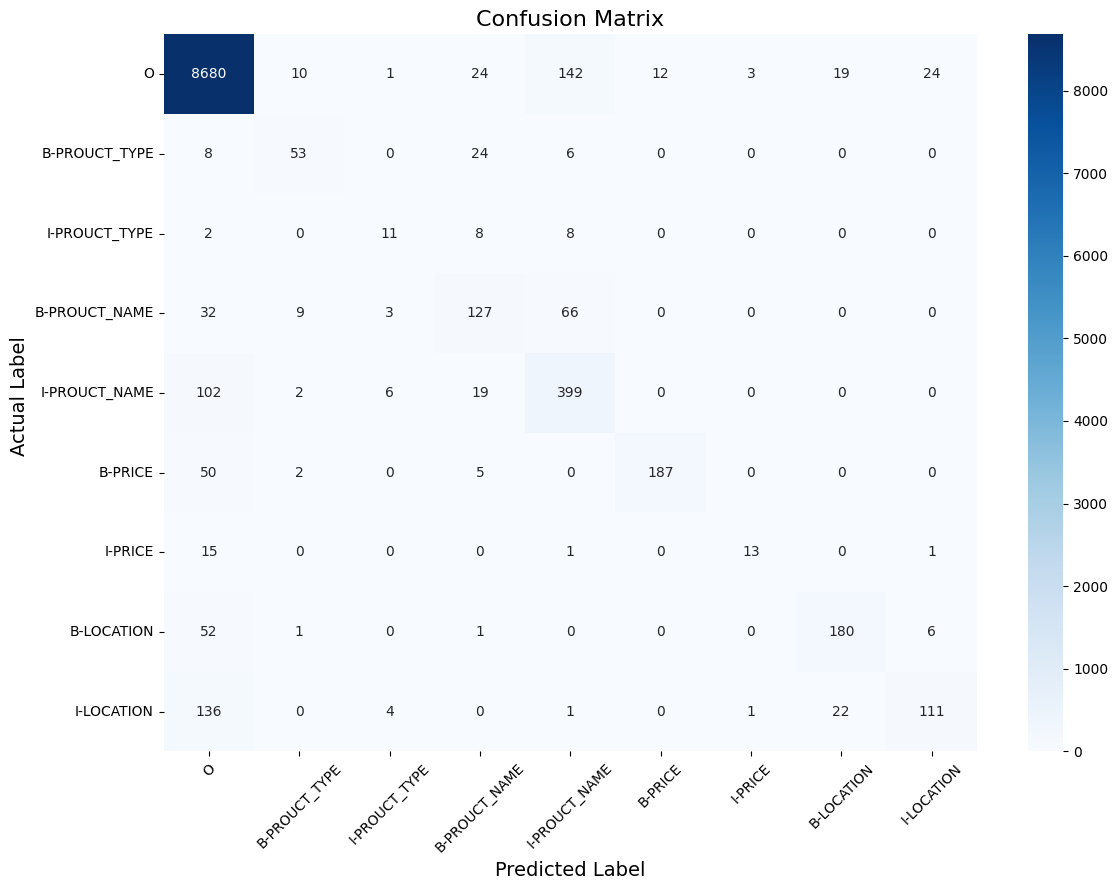

In [115]:
cm = result["confusion_matrix"]

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=label_list,
    yticklabels=label_list
)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Label ', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()